In [2]:
%cd ..
%pwd

/home/cveihmeyer_umass_edu/HeST


'/home/cveihmeyer_umass_edu/HeST'

In [3]:
import os
import sys
import HeST as hest
import HeST.Amherst_split_cpd_with_numba as examp
import numpy as np
import matplotlib.pyplot as plt
import HeST.Detection as detection
from numba import jit
# from tqdm import tqdm
from analysis.analysis_functions import *
import astropy.stats as astat
from scipy.interpolate import interp1d
import pickle
import scipy
import glob
import pandas

In [ ]:
# need to load in the evaporation file (which is a pickle) and make the basic plots


with open('./data/new_batch_pracrice.pkl', 'rb') as f:
    slurm_practice = pickle.load(f)





In [ ]:
plot_hist_flavors(slurm_practice)

In [16]:
phonon = np.linspace(0.2, 0.4, 3)
r_minus = np.linspace(0.15, 0.45, 3)
r_plus = np.linspace(0.3, 0.7, 3)


pp, rm, rp = np.meshgrid(phonon, r_minus, r_plus)

combinations = np.round(np.column_stack((pp.ravel(), rm.ravel(), rp.ravel())), 3)

In [17]:
print(combinations)

[[0.7  0.15 0.3 ]
 [0.7  0.15 0.5 ]
 [0.7  0.15 0.7 ]
 [0.8  0.15 0.3 ]
 [0.8  0.15 0.5 ]
 [0.8  0.15 0.7 ]
 [0.9  0.15 0.3 ]
 [0.9  0.15 0.5 ]
 [0.9  0.15 0.7 ]
 [0.7  0.3  0.3 ]
 [0.7  0.3  0.5 ]
 [0.7  0.3  0.7 ]
 [0.8  0.3  0.3 ]
 [0.8  0.3  0.5 ]
 [0.8  0.3  0.7 ]
 [0.9  0.3  0.3 ]
 [0.9  0.3  0.5 ]
 [0.9  0.3  0.7 ]
 [0.7  0.45 0.3 ]
 [0.7  0.45 0.5 ]
 [0.7  0.45 0.7 ]
 [0.8  0.45 0.3 ]
 [0.8  0.45 0.5 ]
 [0.8  0.45 0.7 ]
 [0.9  0.45 0.3 ]
 [0.9  0.45 0.5 ]
 [0.9  0.45 0.7 ]]


In [19]:
# write a file name 
import time 
import os
# this will be used in the saving that we do later, so I should add this line to HeST basic script
name_directory =os.path.join('', time.strftime('%y%m%d', time.gmtime()))

import numpy as np
num_quasiparticles = np.random.randint(low = 10000, high= 60000, size=1000)

with open(os.path.join('parameters', 'sweep_mom_bins.txt'), 'a+') as f:
    for i, eff in enumerate(combinations):
        f.write(f'/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_mom_bins/trial_{i}.pkl')
        f.write(' ')
        f.write(' ')
        for ii in eff:
            f.write(f'{ii},')
        f.write('\n')


In [ ]:
# the goal of this is to sweep through the files, collect the channel sums, and then move save that and move on. 
import glob
file_list = glob.glob('./data/sample_1000/*')

channel_1 = np.empty(len(file_list))
channel_2 = np.empty(len(file_list))
for i, file in enumerate(file_list):
    with open(file, 'rb') as f:
        evap = pickle.load(f)
        channel_1[i] = len(evap.arrivalTimes_us[0])
        channel_2[i] = len(evap.arrivalTimes_us[1])
np.savetxt('./data/ch1_ch2_comparison/sample_run_data.txt', np.column_stack((channel_1, channel_2)))
config = {}
config['diff_prob'] = 0.8
config['refl_prob'] = 0.3
config['evap_eff'] = 0.6
config['num_qps'] = 10000
with open("config.txt", "w+") as file:
    for key, value in config.items():
        file.write(f"{key}={value}\n")

In [ ]:
fig, ax = plt.subplots(figsize = (6,6))
ax.scatter(channel_1, channel_2)
ax.set_aspect('equal',adjustable= 'box')
ax.set_xlim(0, 8000)
ax.set_ylim(0, 8000)

In [ ]:
templates = np.load('./data/dispersion_curves/templates.npy')
time = np.linspace(0, 10, 25000)
cpd1_scint_template = templates[0]
cpd2_scint_template = templates[1]
cpd1_evap_template = templates[2]
cpd2_evap_template = templates[3]
fig, ax = plt.subplots()
ax.plot(time, cpd1_scint_template, label= 'cpd1 scint')

ax.plot(time, cpd2_scint_template, label = 'cpd2 scint')
ax.plot(time, cpd1_evap_template, label = 'cpd1 evap')
ax.plot(time, cpd2_evap_template, label = 'cpd2 evap')
ax.set_title('Will Template Vs Old Template')
ax.legend()
ax.set_xlim(0, 2.5)

In [ ]:
# sampling rate is 1.25e6 per second: meaning that per each thing has 1/1.25e6 --> 0.8e-6 still the same as before. 
# now we need to save 
upper = int(5 * 2500)
lower = int(1.25*2500)
time = np.linspace(0, 10, 25000)
cpd1_scint_template = templates[0]
cpd2_scint_template = templates[1]
cpd1_evap_template = templates[2]
cpd2_evap_template = templates[3]
fig, ax = plt.subplots()
ax.plot(time[lower:upper], cpd1_scint_template[lower:upper], label= 'cpd1 scint')
ax.plot(time[lower:upper], cpd2_scint_template[lower:upper], label = 'cpd2 scint')
ax.plot(time[lower:upper], cpd1_evap_template[lower:upper], label = 'cpd1 evap')
ax.plot(time[lower:upper], cpd2_evap_template[lower:upper], label = 'cpd2 evap')
ax.set_title('Will Template Vs Old Template')
ax.legend()
ax.set_xlim(0, 2.5)

In [ ]:
print(time[-3] - time[-4])

 # this should be in us I think... 

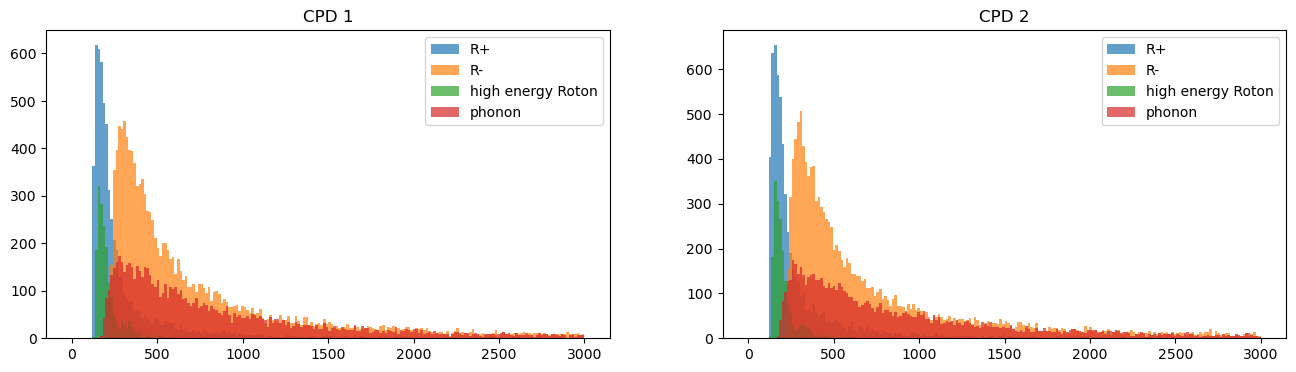

<Figure size 640x480 with 0 Axes>

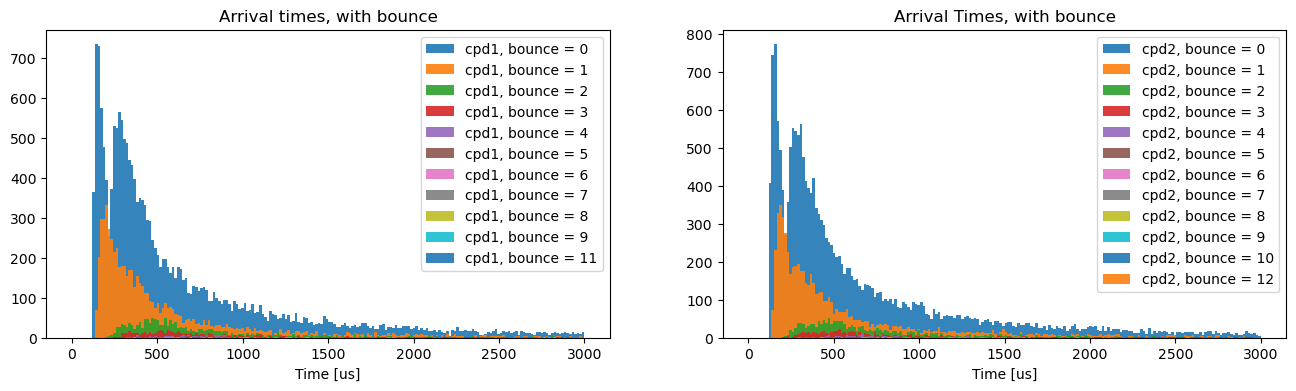

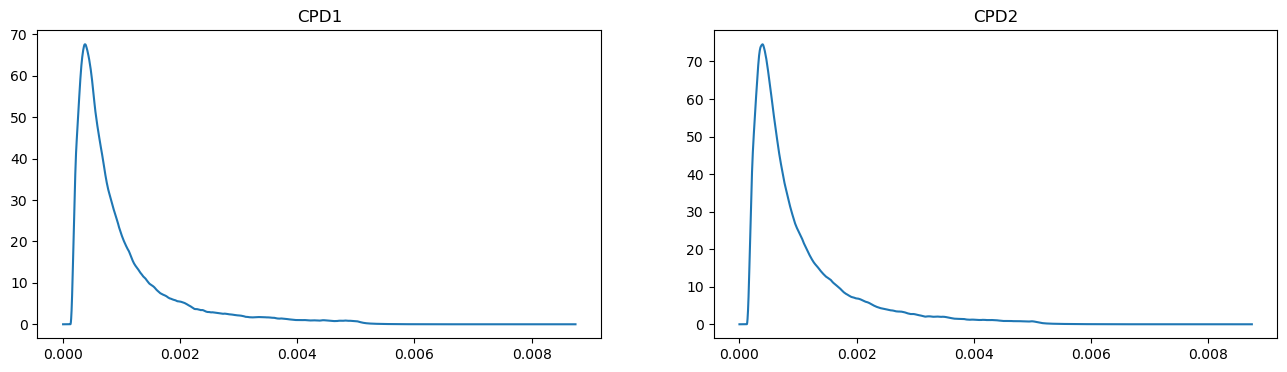

In [3]:
# need to load in the evaporation file (which is a pickle) and make the basic plots


with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_15_z_1.5_test.pkl', 'rb') as f:
    many_qps = pickle.load(f)
plot_hist_flavors(many_qps)
plot_stacked_hist(many_qps)
plot_waveform(many_qps)

In [5]:
time = np.arange(0, 9999 * 0.8e-6, 0.8e-6)

In [ ]:
cpd1_hits = np.histogram(many_qps.arrivalTimes_us[0], bins=3750, range = [0,3000])[0] * 10e-3
cpd2_hits = np.histogram(many_qps.arrivalTimes_us[1], bins=3750, range = [0,3000])[0] * 10e-3
plt.plot(time, np.convolve(cpd1_hits, cpd1_template))

plt.xlabel('Seconds')
plt.ylabel('Energy')
plt.title('CPD 1 pulse comparison')

In [ ]:
s1, s2, time = generate_waveform(many_qps)
plt.plot(time, s1)

In [ ]:
plt.hist(many_qps.arrivalTimes_us[0], bins=200, range = [0,3000])

In [11]:
# I want to read these in by height, and then I can move from there
h_10_files = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_10_*.pkl')
h_15_files = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_15_*.pkl')
h_5_files = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_5_*.pkl')
h_2_5_files = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_2.5_*.pkl')
print(h_15_files)

['/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_15_z_1.5.pkl', '/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_15_z_1.5_test.pkl', '/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_15_z_14.5.pkl', '/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_15_z_4.5.pkl', '/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_15_z_9.5.pkl']


[array([1401.9132925 ,  139.42597436, 3341.92072336, ..., 2053.39221682,
         247.4659682 ,  624.82706466]),
 array([ 286.7521353 ,  155.45769663, 1031.89742795, ...,  283.20720718,
        1064.14960834,  918.76641525]),
 array([ 737.68074503, 7634.27631801,  367.91579933, ..., 9051.97047993,
         138.84037719, 2036.34772954]),
 array([  261.62407956,   236.27654187, 11268.48793184, ...,
          499.38777271,   946.33551855,   292.38329989]),
 array([ 187.0866436 , 4265.33293068,  310.52700685, ..., 1547.49284692,
         175.50903965,  502.79955251]),
 array([ 105.48868355,  477.51987873, 2238.86857347, ...,  480.22248995,
         530.59343223, 1252.70323594])]

<Figure size 640x480 with 0 Axes>

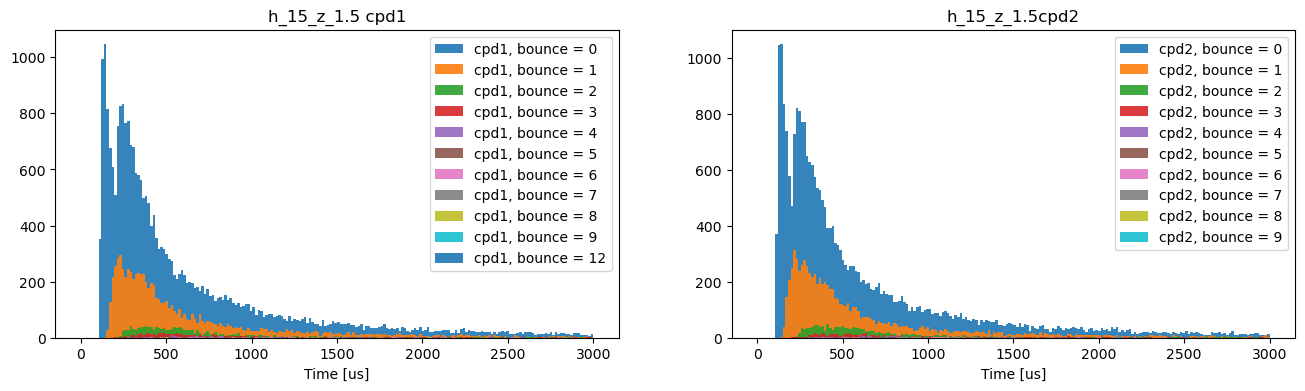

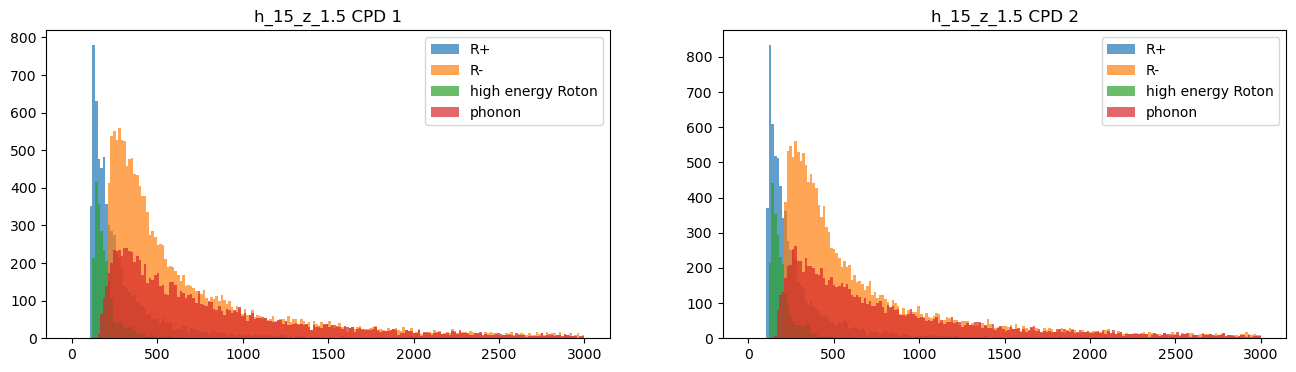

<Figure size 640x480 with 0 Axes>

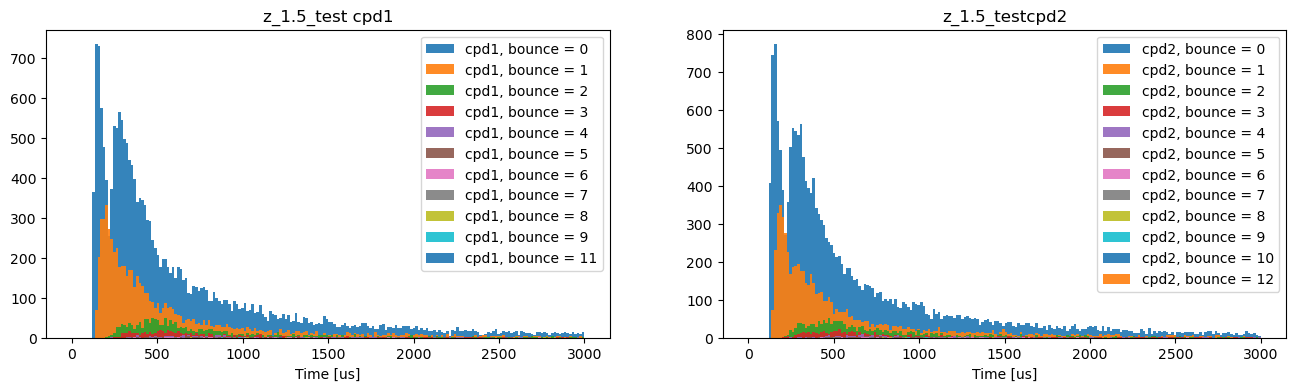

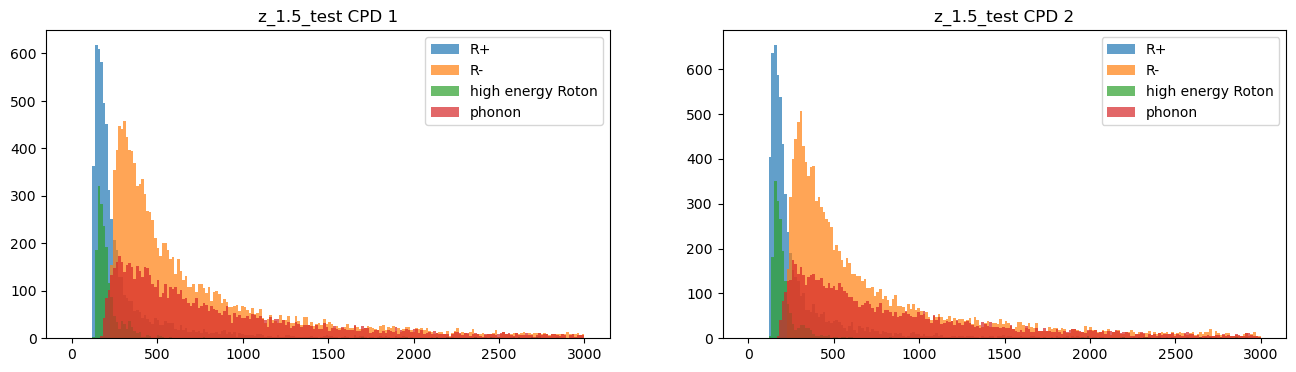

<Figure size 640x480 with 0 Axes>

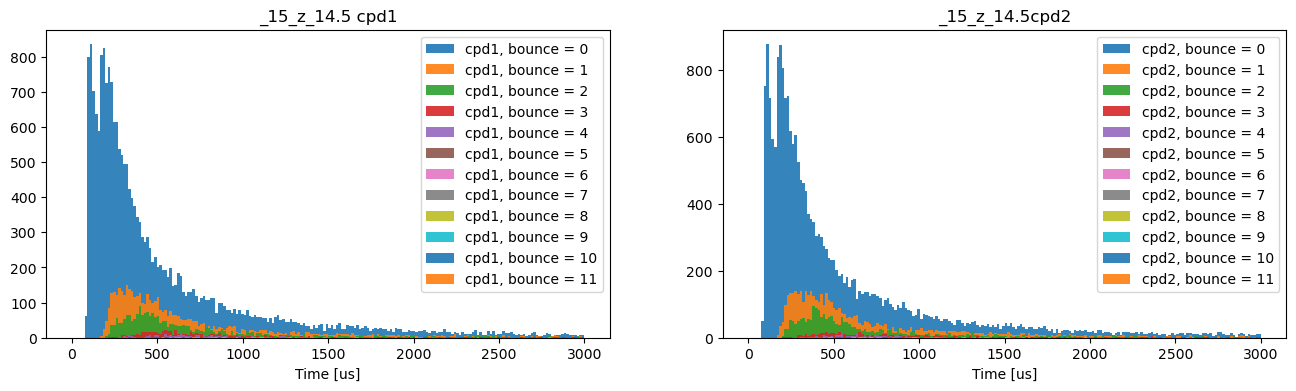

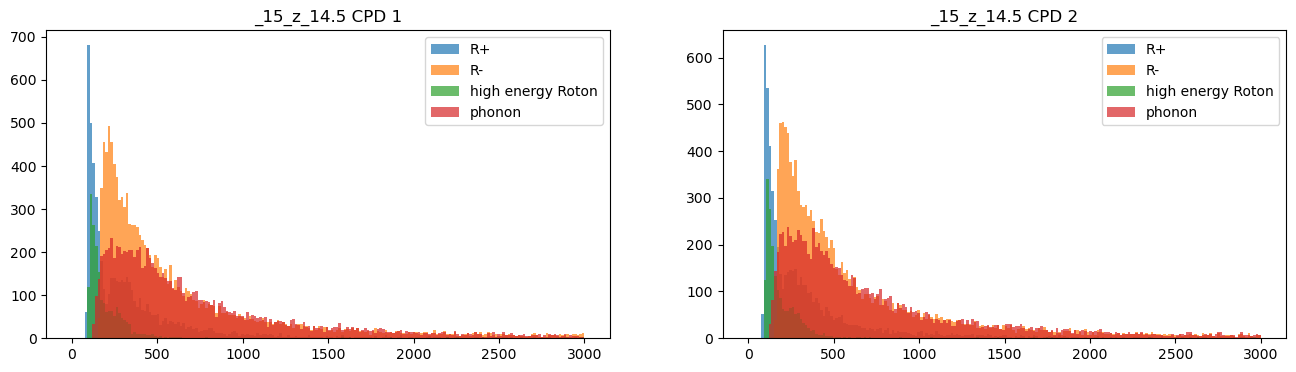

In [10]:
extract_pulse(h_15_files[:3])

[array([150.79578135, 358.25380115,  48.23116157, ...,  44.20853352,
        159.40628542,  54.6027611 ]),
 array([ 52.26022198,  69.29044604, 269.36408767, ..., 224.05987343,
         89.01614955,  54.84945158])]

<Figure size 640x480 with 0 Axes>

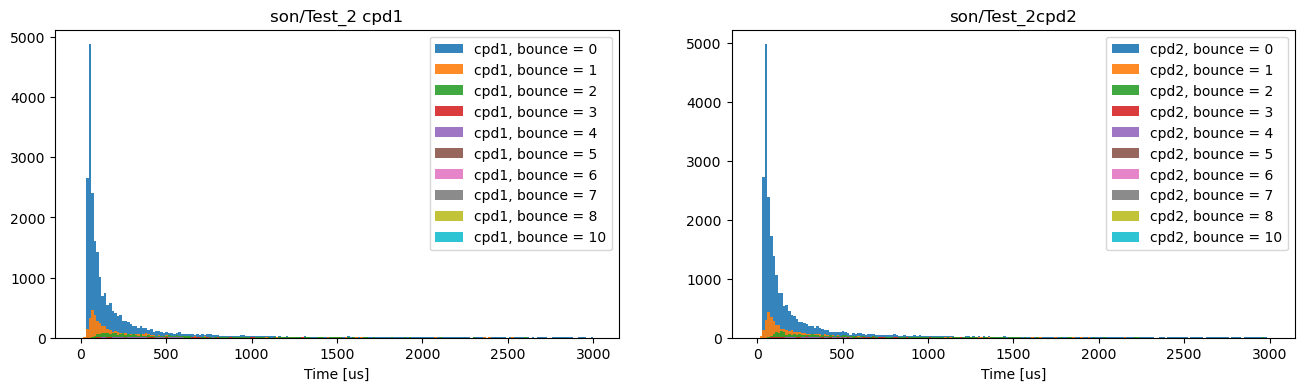

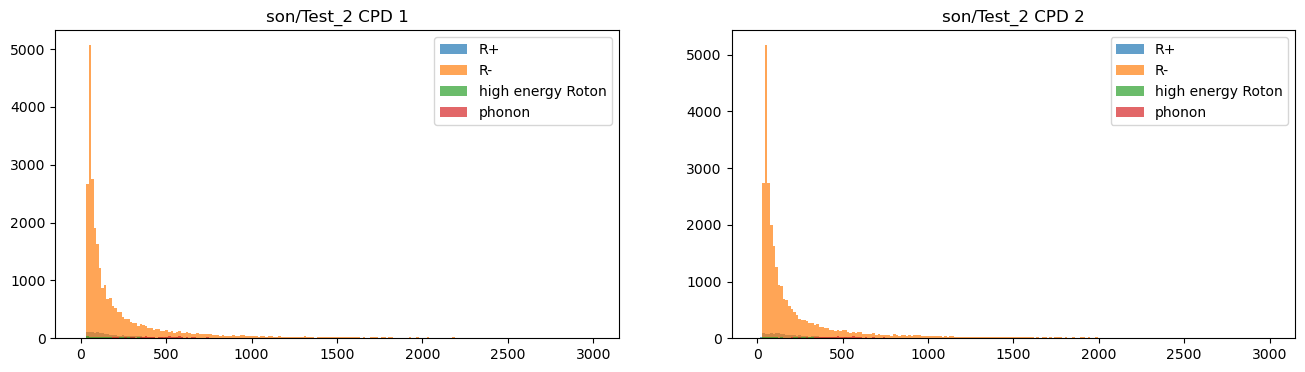

In [4]:
extract_pulse(['/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/Test_2.pkl'])

/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_10_z_1.5.pkl
/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_10_z_4.5.pkl
/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_10_z_9.5.pkl
/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_15_z_1.5.pkl
/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_15_z_1.5_test.pkl
/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_15_z_14.5.pkl
/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_15_z_4.5.pkl
/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_15_z_9.5.pkl
/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_2.5_z_1.5.pkl
/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_5_z_1.5.pkl
/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_5_z_4.5.pkl


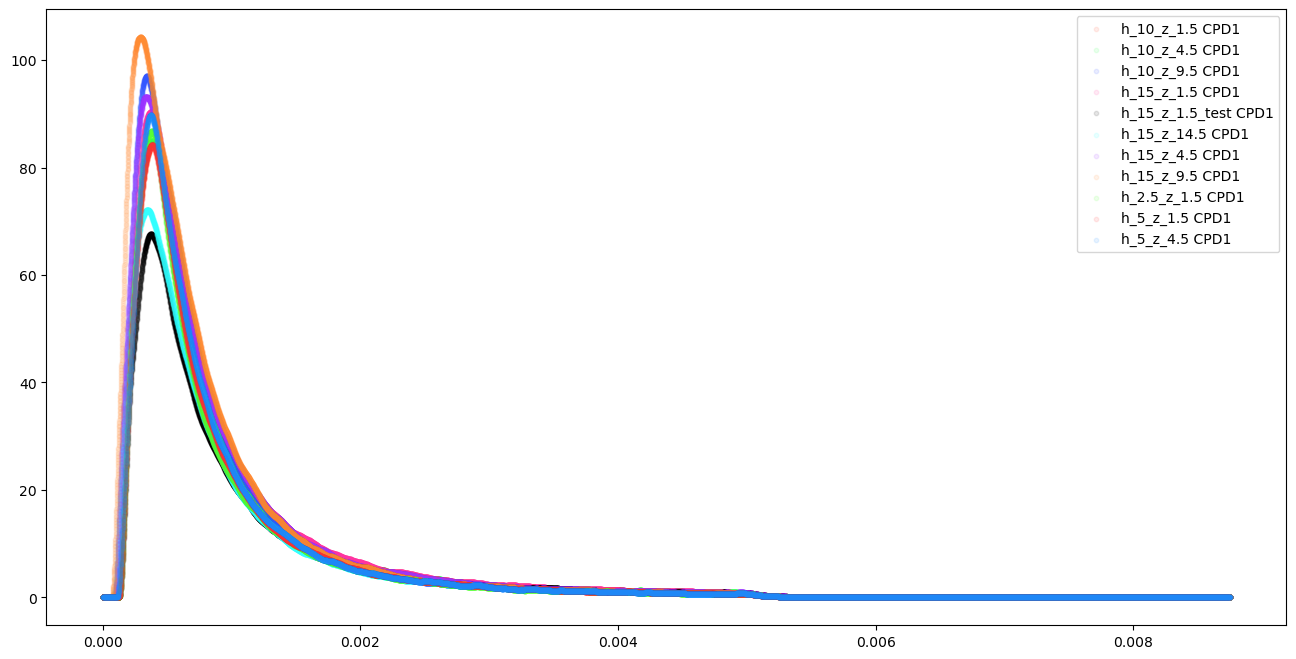

In [4]:
hex_colors = [
    "#FF5733", "#33FF57", "#3357FF", "#FF33A1", "#000000",
    "#33FFFF", "#A133FF", "#FF8C33", "#57FF33", "#FF3333",
    "#1E90FF", "#FFD700"  # Added Dodger Blue and Gold
]

markers = ["o", "s", "^", "v", "D", "X", "P", "*", "H", "<"]

all_files = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h*.pkl')
names = []
waveforms = []
fig, ax = plt.subplots(figsize=(16, 8))
for ii, f in enumerate(all_files):
    print(f)
    with open(f, 'rb') as file:
        evap = pickle.load(file)
    name = f.split('/')[-1][:-4]
    names.append(name)
    s1, s2, time = generate_waveform(evap)
    waveforms.append([s1, s2])
    ax.scatter(time, s1, color=hex_colors[ii],s=10 ,label=name + ' CPD1',  alpha=0.1 ) 
    # ax.plot(time, s1, label=name + ' CPD2') 


ax.legend()

    
    


In [ ]:
fig, ax = plt.subplots()
ax.plot(time[lower:upper] - 0.001, 88 * cpd1_evap_template[lower:upper] / 1921619327.2159166, label = 'cpd1 evap')

In [ ]:
file = all_files[0]
print(file.split('/'))
name = file.split('/')[-1]
print(name[:-4])

In [5]:
# for each, I want to store the cpd time arrays, so we need a 3D thing

def extract_pulse(file_list):
    heights = []
    for ii, file in enumerate(file_list):
        with open(file, 'rb') as f:
            height = pickle.load(f)
        
        plot_stacked_hist(height, title=file_list[ii][-14:-4])
        plot_hist_flavors(height,title=file_list[ii][-14:-4] )
        cpd1 = height.arrivalTimes_us[0]
        cpd2 = height.arrivalTimes_us[1]
        heights.append(cpd1)
        heights.append(cpd2)
    return heights

h_15 = extract_pulse(h_15_files)

NameError: name 'h_15_files' is not defined

In [ ]:
plt.title(str(h_15_files[0])[-14:-4])
plt.hist(h_15[0], bins=200, range = (0,3000))

In [12]:
templates = np.load('./data/dispersion_curves/templates.npy')
time = np.linspace(0, 0.01, 25000)
cpd1_scint_template = templates[0]
cpd2_scint_template = templates[1]
cpd1_evap_template = templates[2]
cpd2_evap_template = templates[3]

In [ ]:
with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/Test.pkl', 'rb') as f:
    evap = pickle.load(f)
# plot_stacked_hist(evap)
# plot_hist_flavors(evap)
plot_waveform(evap)
plt.plot(time - 0.0011, 110 * cpd2_evap_template)

In [ ]:
file_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/*.pkl')
for ii, f in enumerate(file_list):
    if ii%2==0 or ii%5==0:
        continue
    print(f)
    title = f.split('/')[-1][:-4]
    with open(f, 'rb') as file:
        evap = pickle.load(file)
    
    plot_hist_flavors(evap, title = title)
    if ii>50:
        break

In [6]:
file_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/*.pkl')
print(file_list)

['/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/params_0.1_0.1.pkl', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/params_0.1_0.2.pkl', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/params_0.1_0.3.pkl', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/params_0.1_0.4.pkl', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/params_0.1_0.5.pkl', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/params_0.1_0.6.pkl', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/params_0.1_0.7.pkl', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/params_0.1_0.8.pkl', '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/params_0.1_0.9.pkl', '/work/pi

[array([ 41.73500718, 345.28124295,  80.99399011, ..., 292.51918476,
         56.73719799,  46.70602184]),
 array([  346.81100518,   347.54936601,   116.84445372, ...,
        17214.14292726,   237.9026251 ,    92.10788012]),
 array([7847.92531408,  340.22097133,   42.48918821, ...,   95.57104187,
         645.04766442,  146.15172143]),
 array([460.74590057, 502.9684254 , 162.27230686, ..., 280.28626746,
         41.73500718, 457.19761087]),
 array([ 44.5307918 ,  57.71448728,  52.02336097, ...,  99.73756648,
        306.52655221,  54.95865818]),
 array([ 411.06412882, 2369.95648098, 1419.4185699 , ...,   73.43598572,
          97.06045254,   52.72190302])]

<Figure size 640x480 with 0 Axes>

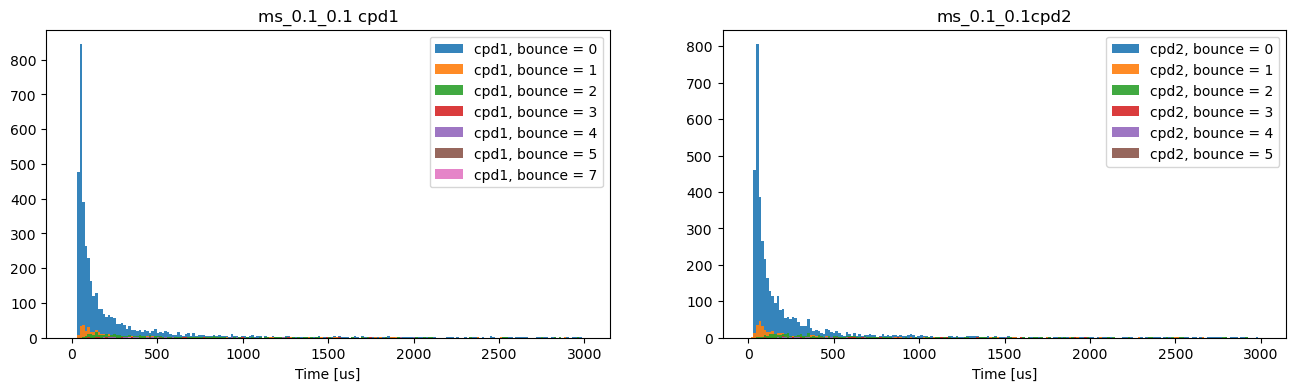

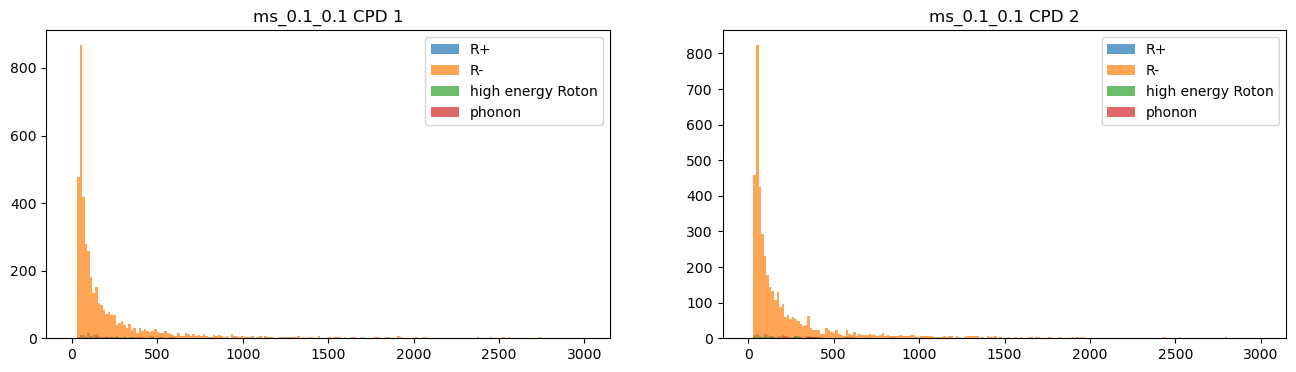

<Figure size 640x480 with 0 Axes>

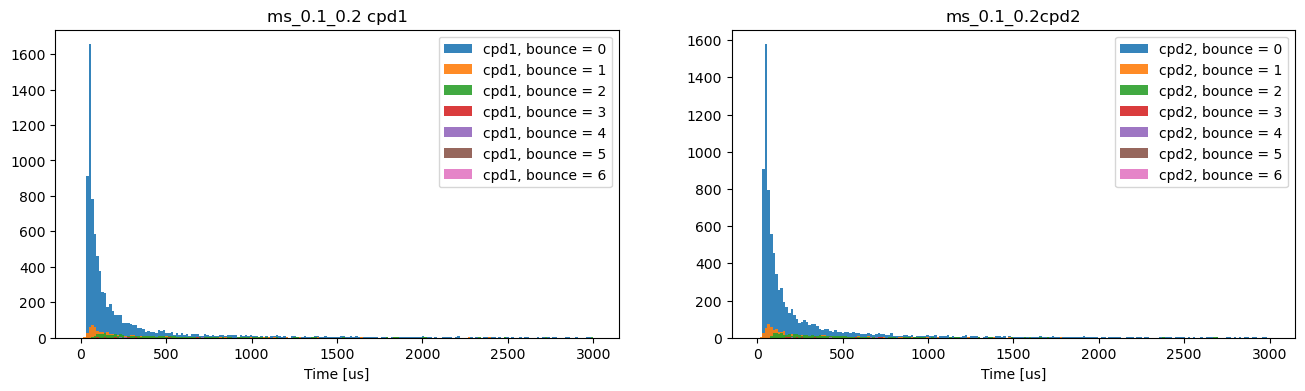

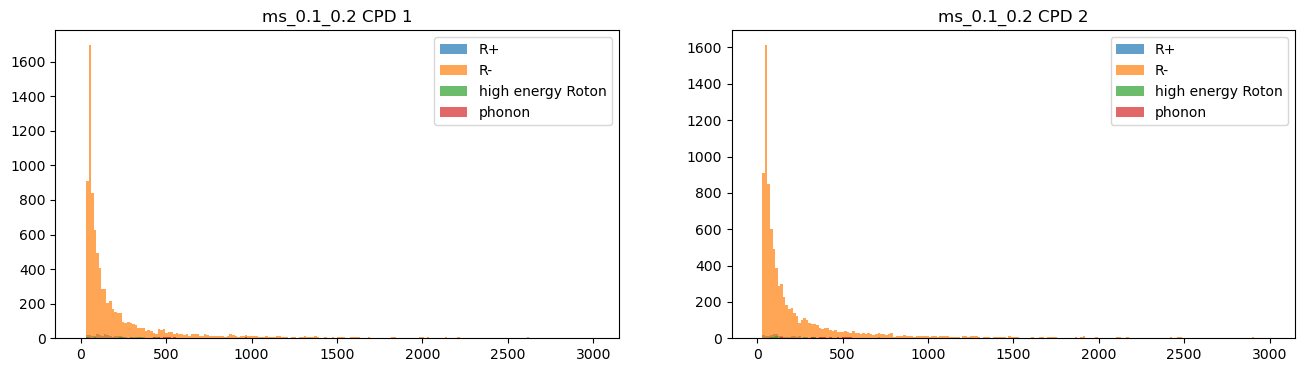

<Figure size 640x480 with 0 Axes>

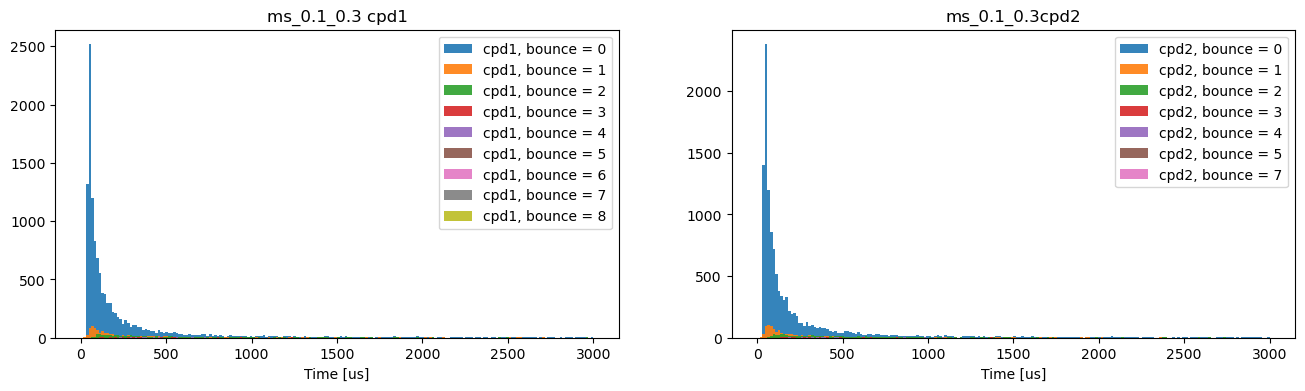

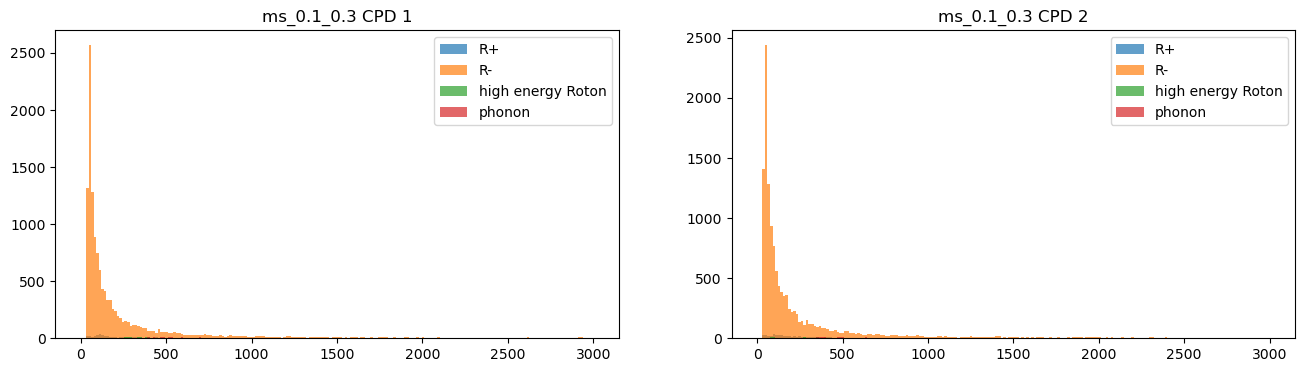

In [7]:
extract_pulse(file_list=file_list[:3])

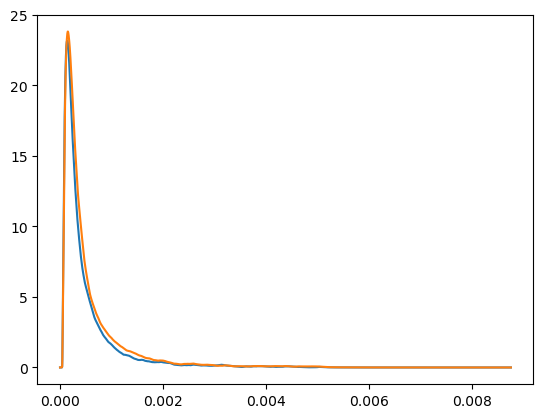

In [4]:
fig, ax = plt.subplots()
with open(file_list[0], 'rb') as f:
    evap = pickle.load(f)
s1, s2, time =generate_waveform(evap)
ax.plot(time, s1, label='CPD1')
ax.plot(time, s2, label='CPD2')

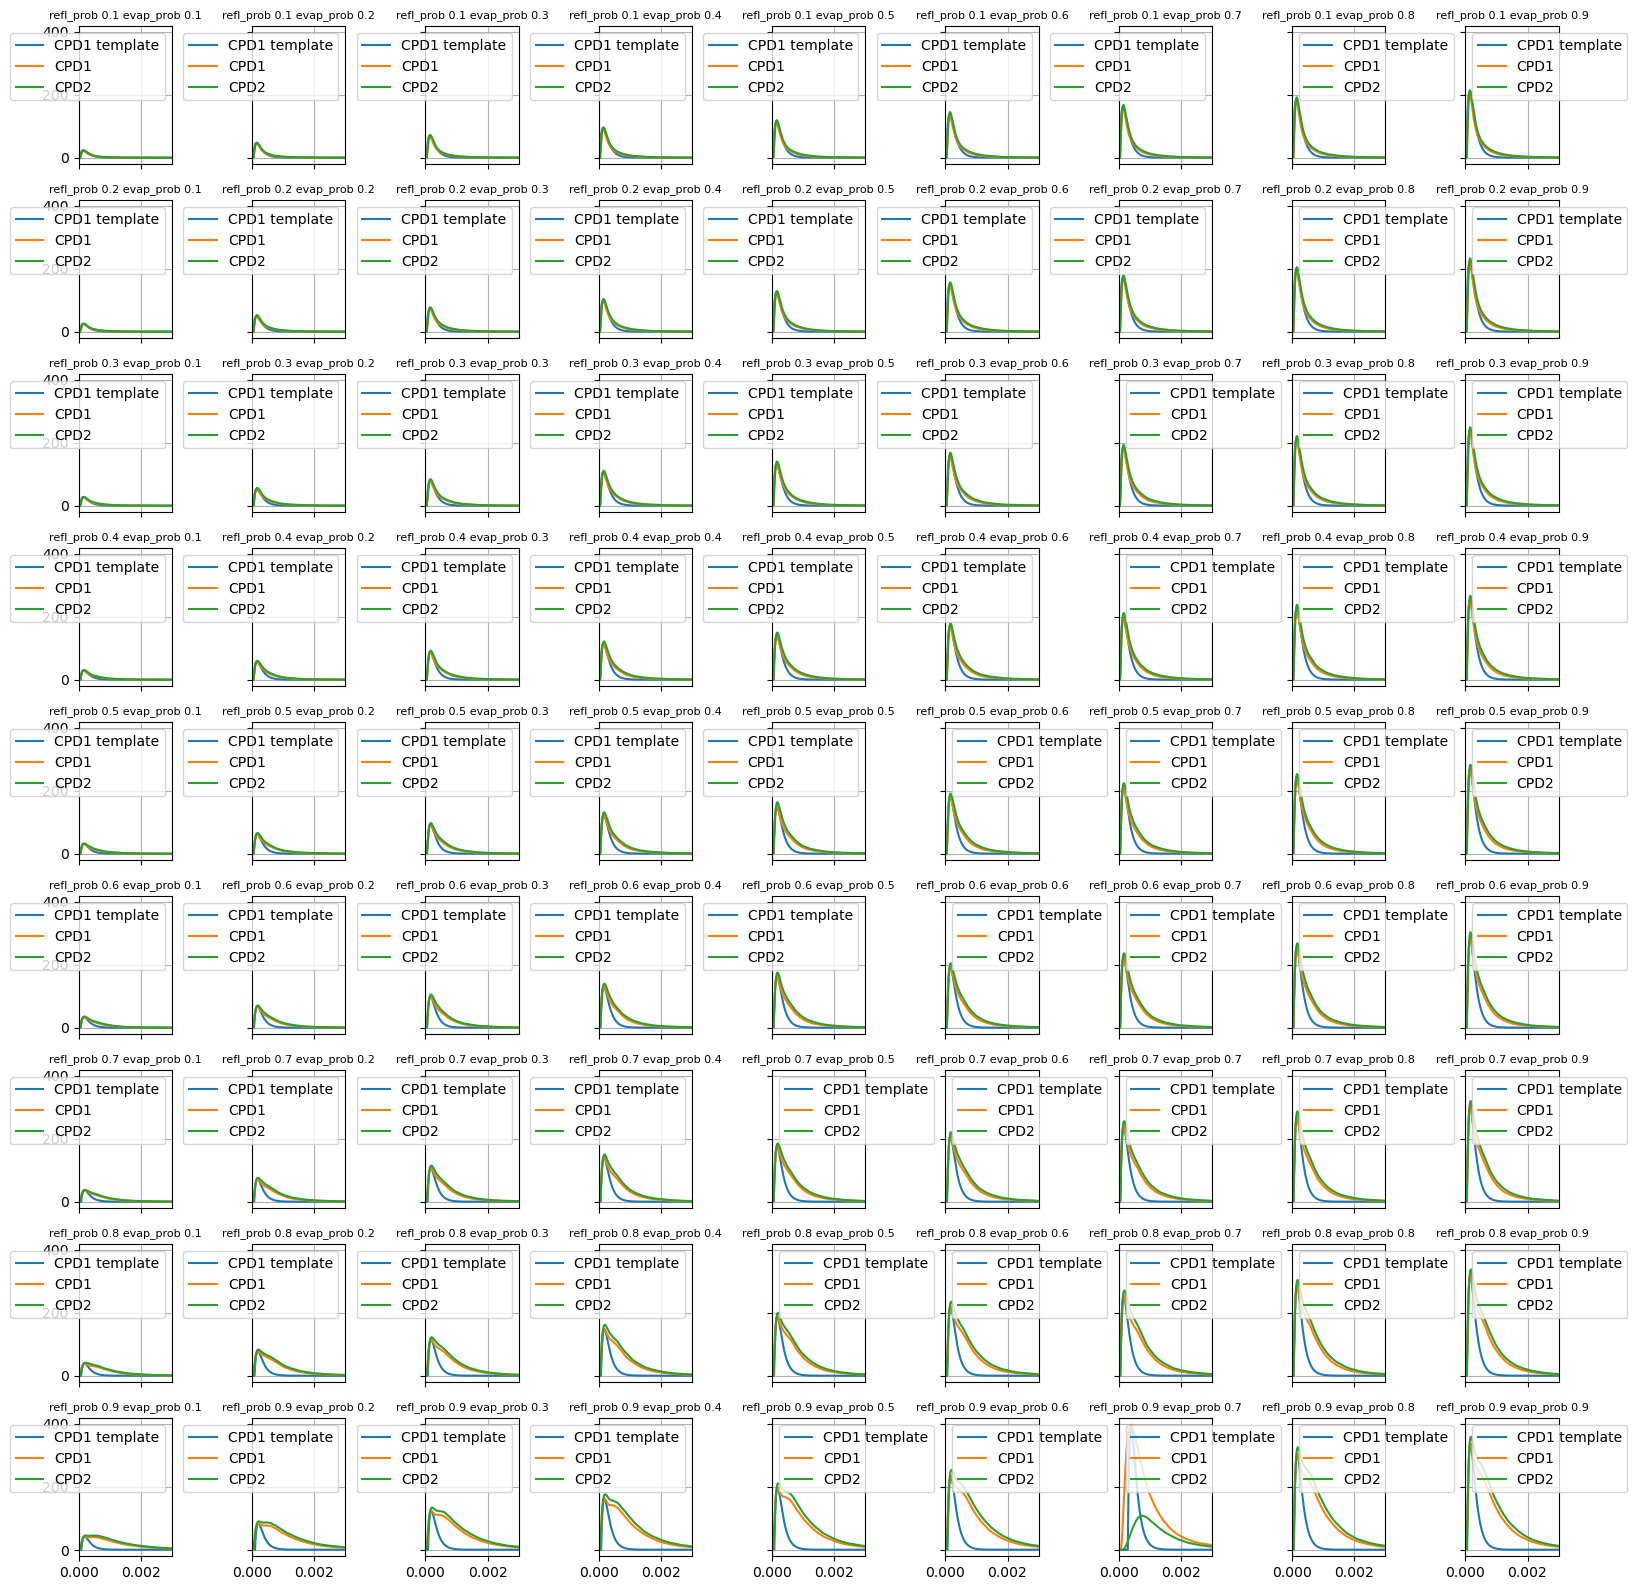

In [7]:
template = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/shortened_template.npy')
template_1 = template[2]
template_2 = template[3]


fig, axs = plt.subplots(9, 9, figsize = (16,16), sharex=True, sharey=True)
ax = axs.flatten()
for i, f in enumerate(np.array(file_list)):
    with open(f, 'rb') as file:
        evap = pickle.load(file)
    title = f.split('/')[-1][:-4]
    refl_prob = title[-7:-4]
    evap_prob = title[-3:]
    s1, s2 , time =generate_waveform(evap)

    peak = np.max(s1)
    peak_index_signal = np.argmax(s1)
    peak_index_template = np.argmax(template_1)
    diff = peak_index_signal - peak_index_template
    before_pad = int(diff)
    after_pad = len(s1) - len(template_1) -before_pad
    new_template = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)  * peak

    ax[i].plot(time, new_template + 1, label = 'CPD1 template')
    ax[i].plot(time, s1, label='CPD1')
    ax[i].plot(time, s2, label='CPD2')
    ax[i].set_title('refl_prob ' + refl_prob + ' evap_prob ' + evap_prob, fontsize=8)
    ax[i].legend()
    ax[i].grid()
    ax[i].set_xlim(0, 0.003)
fig.tight_layout()
fig.savefig('sweep_2d_refl_evap.png', dpi=300)
 

# Understanding Optimal Momentum evaporation efficiency. 


[False False False ...  True False False]
[ True  True  True ... False  True  True]
[False False False ... False False False]
[False False False ... False False False]
[False False False ... False False False]
[ True  True  True ...  True  True  True]
[False False False ... False False False]
[False False False ... False False False]
[False False False ... False False False]
[ True  True  True ...  True  True  True]
[False False False ... False False False]
[False False False ... False False False]
[False False False ... False False False]
[ True False  True ...  True  True  True]
[False  True False ... False False False]
[False False False ... False False False]
[False False False ... False False False]
[ True  True  True ...  True  True  True]
[False False False ... False False False]
[False False False ... False False False]
[False False False ... False False False]
[ True  True  True ...  True  True  True]
[False False False ... False False False]
[False False False ... False False

[array([173.67366238, 216.92902953, 279.48541698, ...,  27.83138811,
        955.24318236,  45.00660408]),
 array([ 57.2797551 , 308.28276529, 106.28957075, ..., 406.09631061,
        133.52241737, 147.1148749 ]),
 array([ 41.87502896, 622.14893001,  52.35648907, ..., 187.07522877,
         80.8230659 , 174.72951831]),
 array([  45.79586504,  356.20735139,  160.72948469, ...,  394.99826948,
          79.08432381, 4665.76542538]),
 array([ 42.98744431,  76.01767727, 756.21920438, ...,  79.76347537,
         81.74235906, 104.8877734 ]),
 array([  122.92514724,   614.46122471,   662.24393395, ...,
        12529.69698406,    47.36880398,    41.73500718])]

<Figure size 640x480 with 0 Axes>

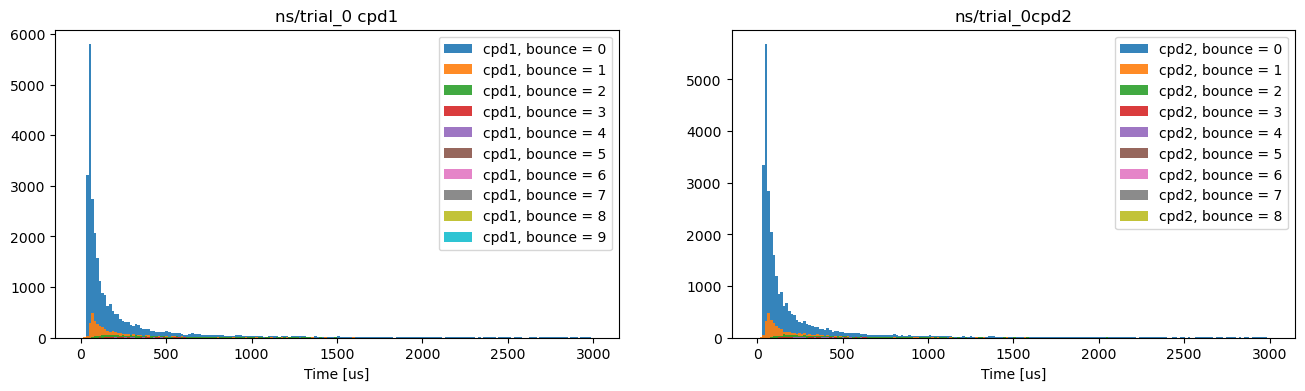

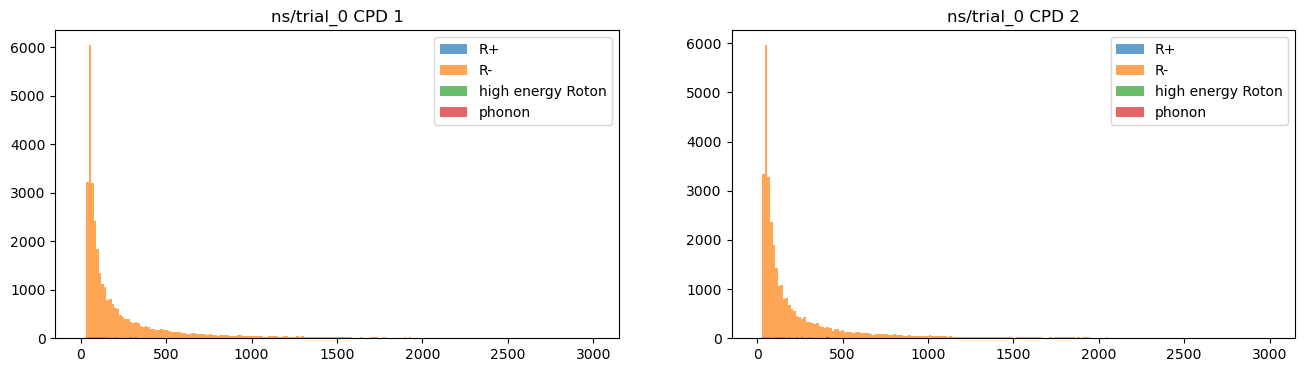

<Figure size 640x480 with 0 Axes>

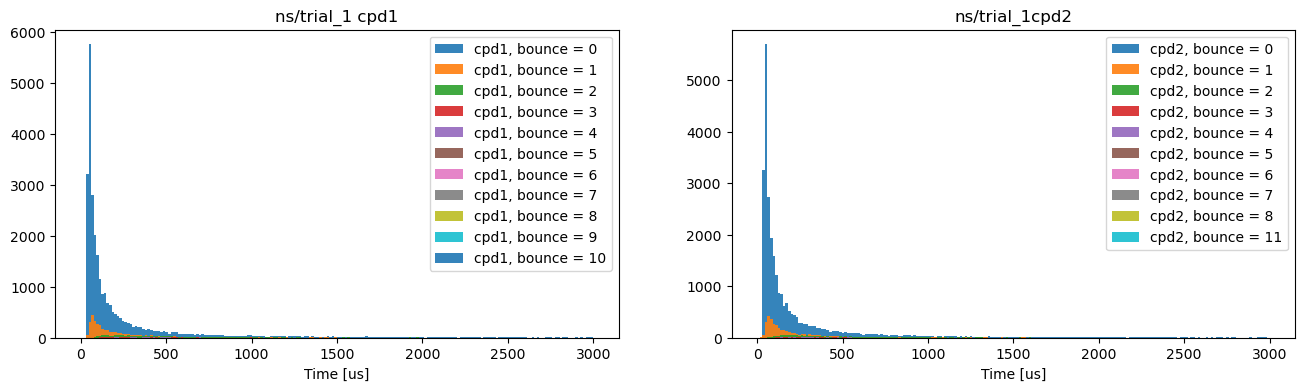

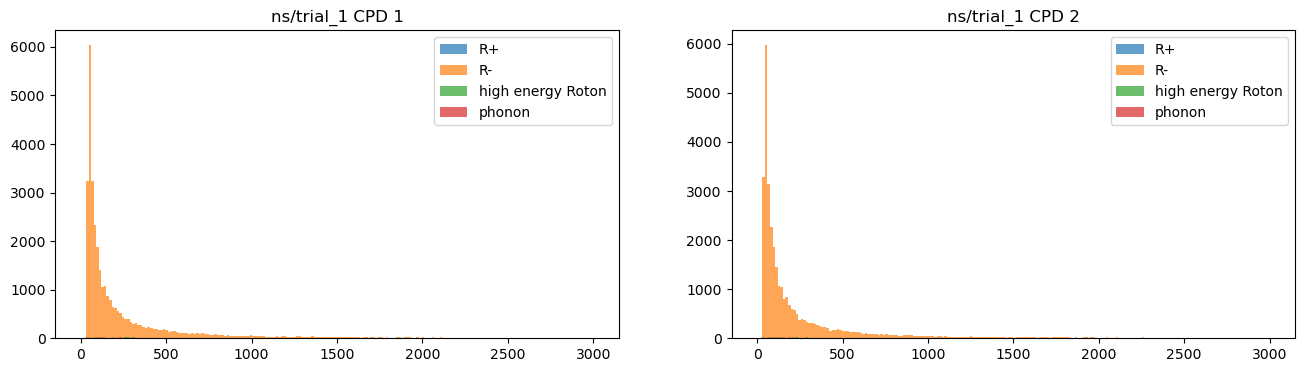

<Figure size 640x480 with 0 Axes>

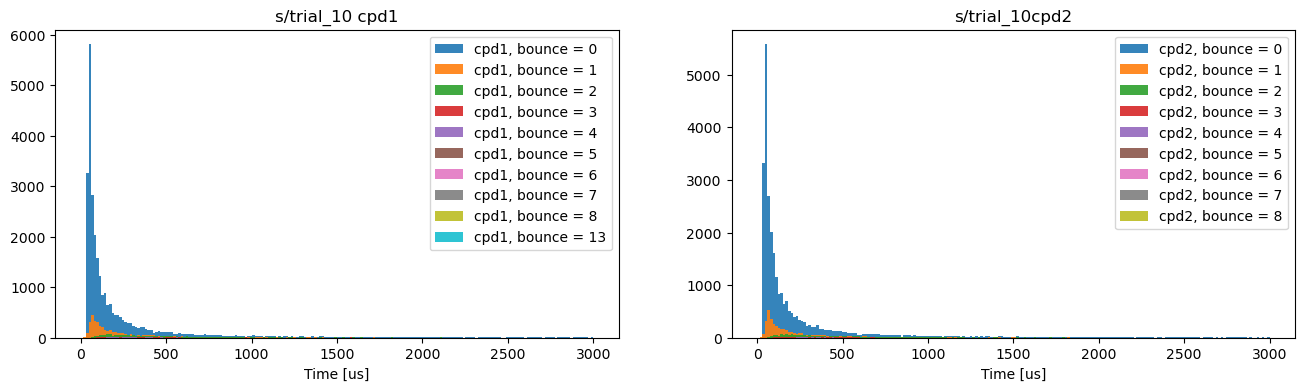

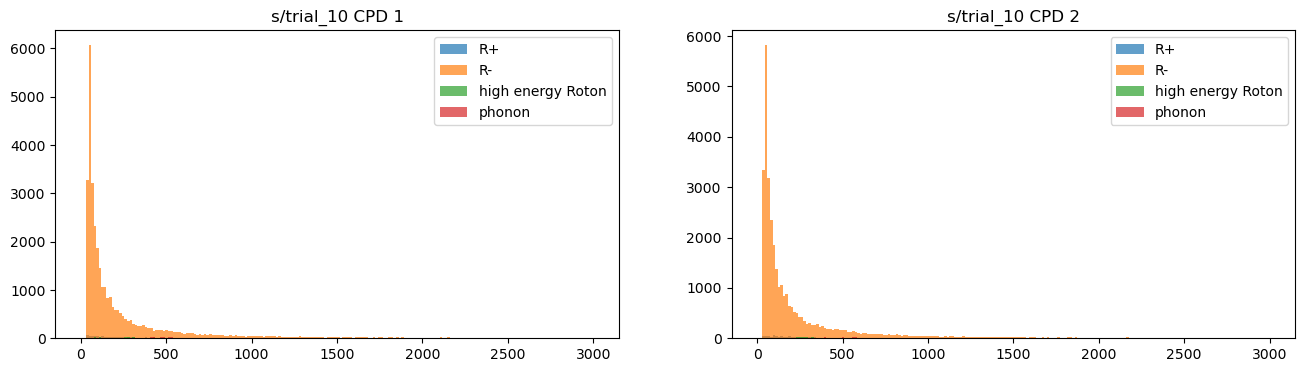

In [9]:
file_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_mom_bins/*.pkl')
extract_pulse(file_list[:3])


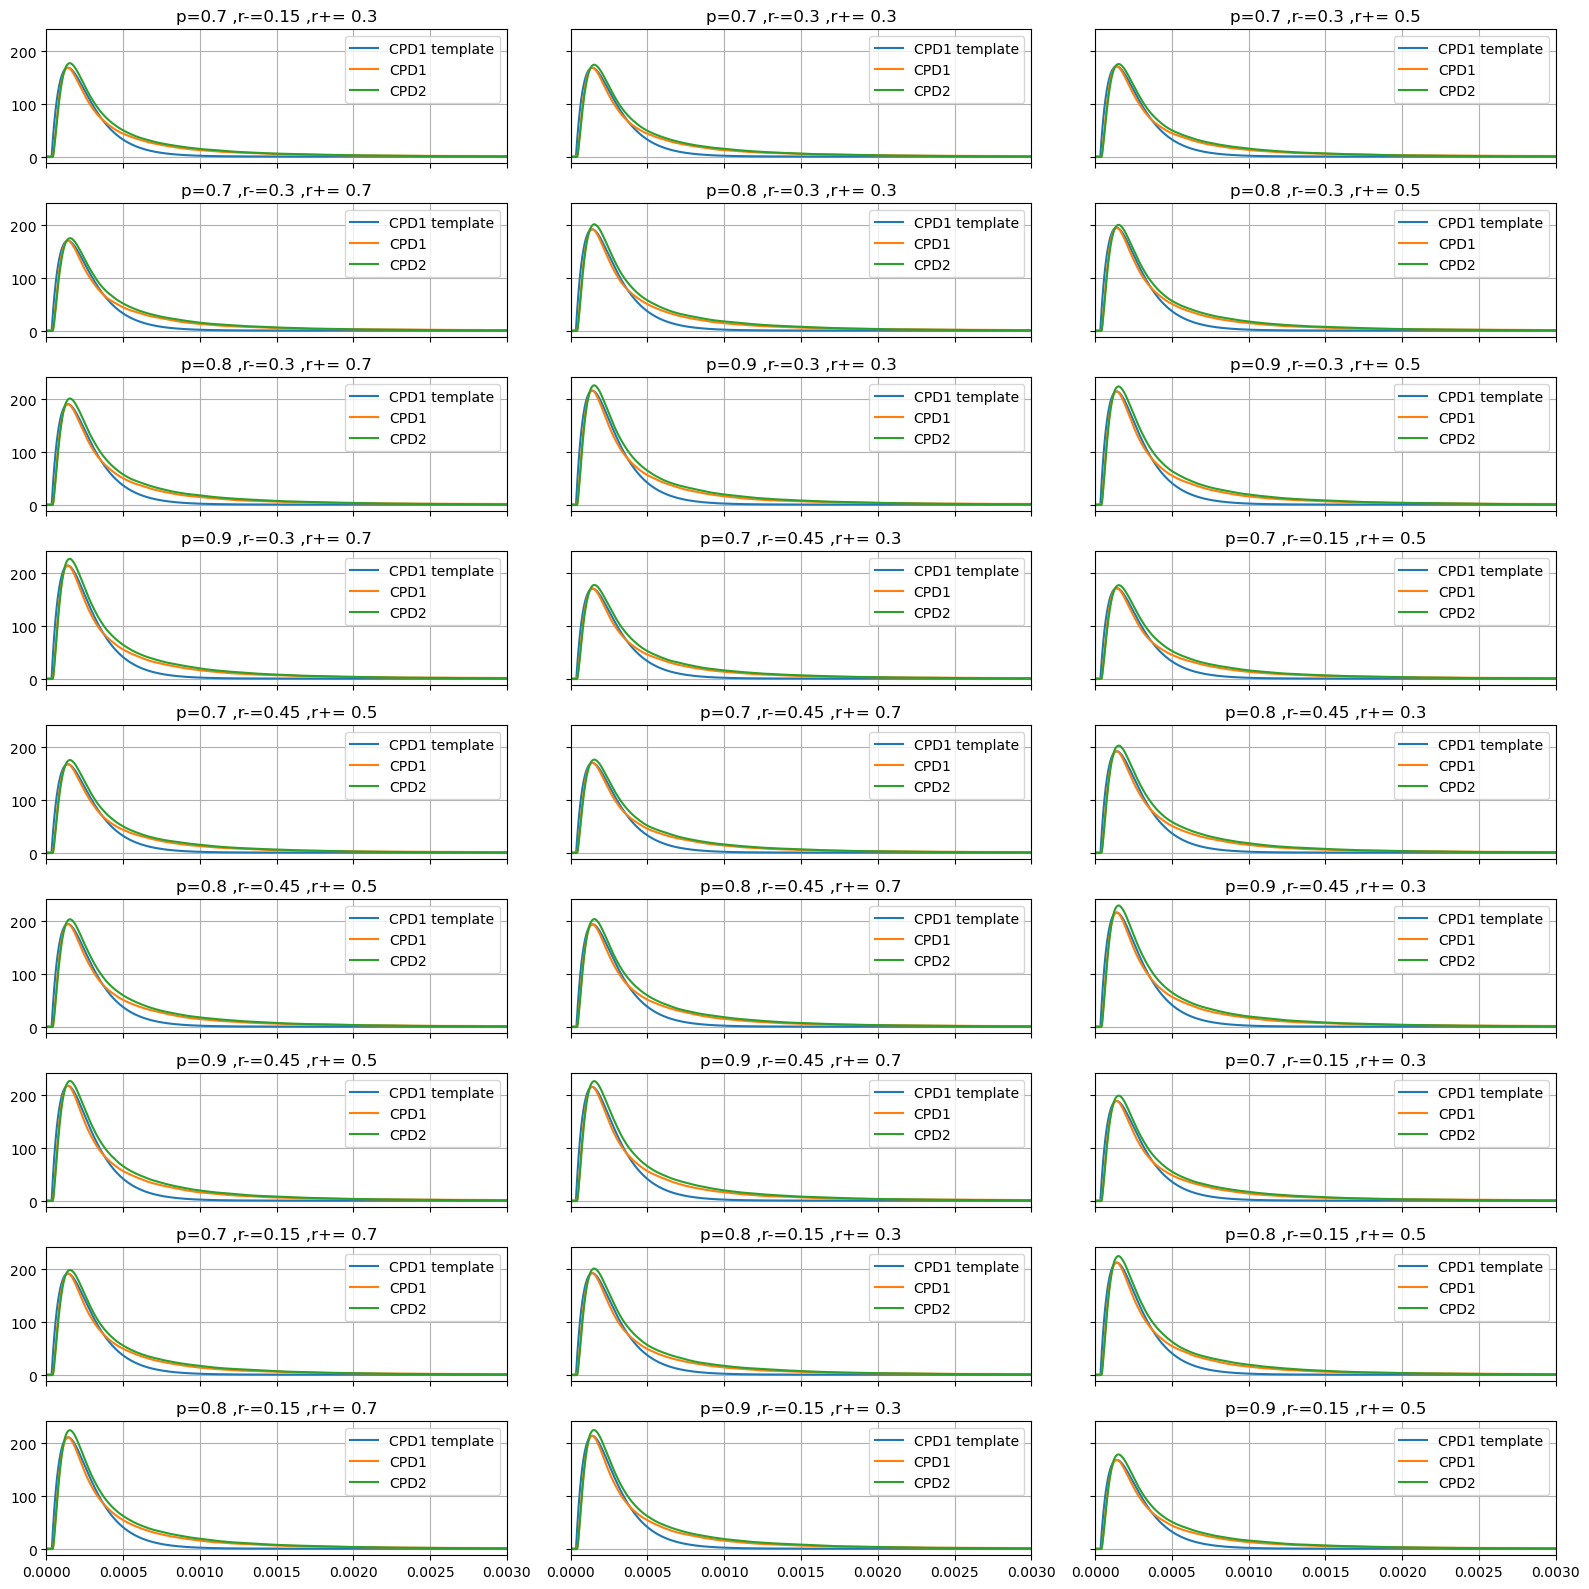

In [8]:
file_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_mom_bins/*.pkl')
config_list= glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_mom_bins/*.csv')
fig, axs = plt.subplots(9, 3, figsize = (16,16), sharex=True, sharey=True)
ax = axs.flatten()
template = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/shortened_template.npy')
template_1 = template[2]
template_2 = template[3]
chi_squared = np.empty_like(file_list, dtype=float)

for i, f1 in enumerate(file_list):

    with open(f1, 'rb') as file:
        evap = pickle.load(file)
    config_file = pandas.read_csv(config_list[i])
    s1, s2 , time =generate_waveform(evap)
    peak = np.max(s1)
    peak_index_signal = np.argmax(s1)
    peak_index_template = np.argmax(template_1)
    diff = peak_index_signal - peak_index_template
    before_pad = int(diff)
    after_pad = len(s1) - len(template_1) -before_pad
    new_template = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)  * peak

    chi_squared[i] = np.sum((s1+1)**2 - (new_template+1)**2/(new_template+1))
    ax[i].plot(time, new_template + 1, label = 'CPD1 template')

    ax[i].plot(time, s1 + 1, label='CPD1')
    ax[i].set_xlim(0, 0.003)
    ax[i].plot(time, s2, label='CPD2')
    ax[i].set_xlim(0, 0.003)
    eff = config_file['evap_eff'].astype('str')
    title = 'p='+ eff[0] + ' ,r-=' + eff[1] + ' ,r+= ' + eff[2]
    ax[i].set_title(title)
    ax[i].legend()
    ax[i].grid()
fig.tight_layout()
 

In [4]:
np.min(chi_squared)

np.float64(14045580.383370047)

In [55]:
config_file = pandas.read_csv(config_list[1])
evap = config_file['evap_eff'].astype('str')
evap[:]

0    0.3
1    0.5
2    0.3
Name: evap_eff, dtype: object

In [24]:
def compare_waveforms(evap):
    template = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/shortened_template.npy')
    template_1 = template[0]
    template_2 = template[1]
    s1, s2, time = generate_waveform(evap)
    if len(template_1) > len(s1):
        diff = len(template_1) - len(s1)
        mins_1 = np.empty((diff))
        mins_2 = np.empty((diff))
        for i in range(diff):
            mins_1[i] = scipy.stats.chisquare(template_1[i:diff-i], s1)
            # mins[i] = scipy.stats.chisquare(template[i:diff])
    if len(template_1) < len(s1):
        diff = len(s1) - len(template_1)

        mins_1 = np.empty((diff))
        mins_2 = np.empty((diff))
        for i in range(diff):
            print(np.shape(template_1[i:diff-i]))
            print(np.shape(s1[i:diff-i]))

            mins_1[i] = scipy.stats.chisquare(s1[i:diff-i], template_1)
            # mins[i] = scipy.stats.chisquare(template[i:diff])
    return np.min(mins_1) 

In [6]:
s1, s2, time = generate_waveform(many_qps)
template = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/shortened_template.npy')
template_1 = template[2]
template_2 = template[3]
print(np.shape(s1))
print(np.shape(template_1))

diff = len(s1) - len(template_1)

peak = np.max(s1)
mins_1 = np.empty((diff))
mins_2 = np.empty((diff))
for i in range(diff):
    try:
        mins_1[i] = scipy.stats.chisquare(s1[i:len(template_1)+i],peak* template_1)
        print('it worked!')
    except ValueError:
        continue



(21874,)
(9375,)


In [13]:
print(mins_1)

[6.44844732e-310 4.92716487e-310 4.92716487e-310 ... 0.00000000e+000
 0.00000000e+000 0.00000000e+000]


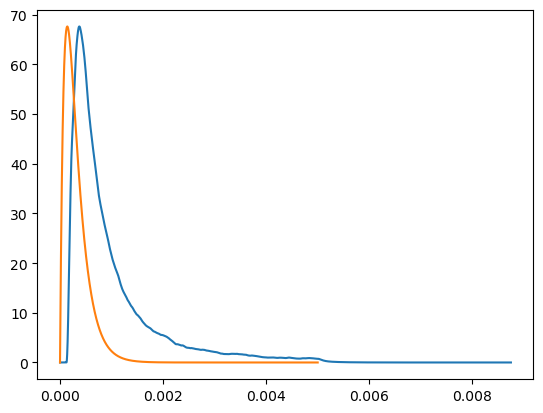

In [11]:

plt.plot(time, s1)
time_2 = np.linspace(0, 0.005, int(9375))

plt.plot(time_2, peak * template_1)

ValueError: For each axis slice, the sum of the observed frequencies must agree with the sum of the expected frequencies to a relative tolerance of 1.4901161193847656e-08, but the percent differences are:
1.5412300883143448

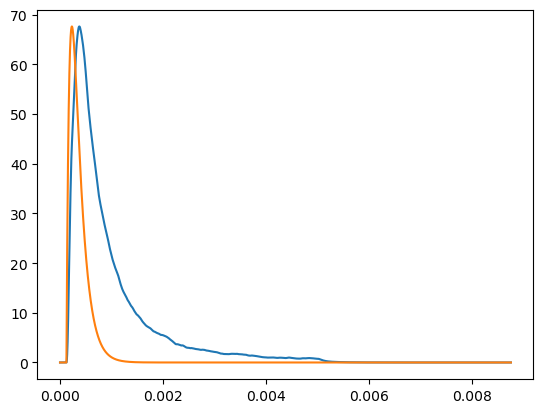

In [18]:
peak_index_signal = np.argmax(s1)
peak_index_template = np.argmax(template_1)
diff = peak_index_signal - peak_index_template
before_pad = int(diff)
before_pad = np.nonzero(s1)[0][0]
after_pad = len(s1) - len(template_1) -before_pad

new_template = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)

plt.plot(time, s1)
plt.plot(time, peak * new_template)
scipy.stats.chisquare(s1, peak * new_template)